# 06 - Naive Bayes

Train and evaluate `GaussianNB` on the lung cancer dataset.
- Tune `var_smoothing` parameter
- Confusion matrix, classification report

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, matthews_corrcoef,
                             confusion_matrix, classification_report, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load processed data
PROCESSED = Path('..') / 'data' / 'processed'
X_train = pd.read_csv(PROCESSED / 'X_train.csv').astype(float)
X_test = pd.read_csv(PROCESSED / 'X_test.csv').astype(float)
y_train = pd.read_csv(PROCESSED / 'y_train.csv').values.ravel().astype(int)
y_test = pd.read_csv(PROCESSED / 'y_test.csv').values.ravel().astype(int)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (447, 15), Test: (112, 15)


In [2]:
# Hyperparameter tuning
neg_ratio = (y_train == 0).sum() / len(y_train)
pos_ratio = (y_train == 1).sum() / len(y_train)

param_grid = {
    'var_smoothing': np.logspace(-12, -1, 50),
    'priors': [None, [neg_ratio, pos_ratio]]
}

nb = GaussianNB()
grid = GridSearchCV(nb, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

Best params: {'priors': None, 'var_smoothing': np.float64(0.1)}
Best CV F1: 0.9491


In [3]:
# Evaluate on test set
best_nb = grid.best_estimator_
y_pred = best_nb.predict(X_test)
y_prob = best_nb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
mcc = matthews_corrcoef(y_test, y_pred)

print("=== Naive Bayes - Test Results ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")
print(f"MCC:       {mcc:.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

=== Naive Bayes - Test Results ===
Accuracy:  0.9196
Precision: 0.9406
Recall:    0.9694
F1-Score:  0.9548
AUC-ROC:   0.9111
MCC:       0.6010

              precision    recall  f1-score   support

           0       0.73      0.57      0.64        14
           1       0.94      0.97      0.95        98

    accuracy                           0.92       112
   macro avg       0.83      0.77      0.80       112
weighted avg       0.91      0.92      0.92       112



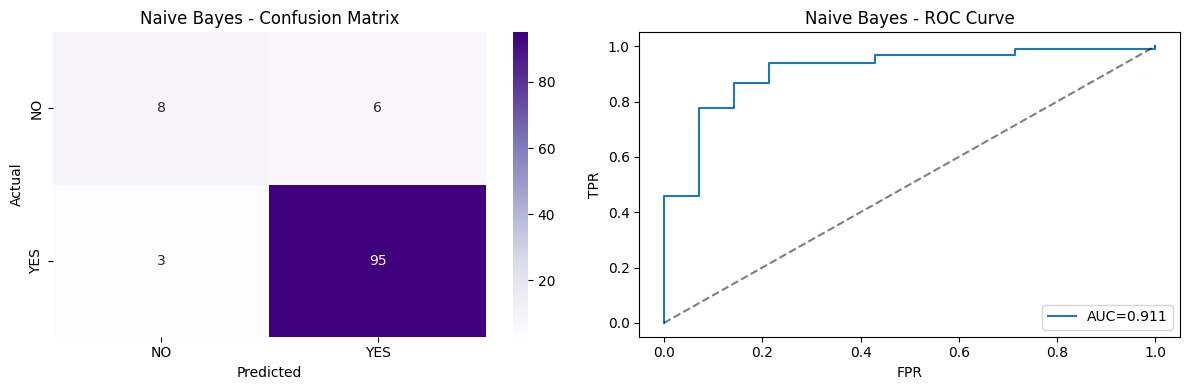

In [4]:
# Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
            xticklabels=['NO','YES'], yticklabels=['NO','YES'])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'k--',alpha=0.5)
axes[1].set_title('Naive Bayes - ROC Curve')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

plt.tight_layout()
plt.savefig('../results/naive_bayes_results.png', dpi=150)
plt.show()

In [5]:
# Save model and results
MODELS_DIR = Path('..') / 'models'
joblib.dump(best_nb, MODELS_DIR / 'naive_bayes.pkl')
results = pd.DataFrame([{
    'Model': 'Naive Bayes', 'Accuracy': acc, 'Precision': prec,
    'Recall': rec, 'F1': f1, 'AUC': auc, 'MCC': mcc
}])
results.to_csv(Path('..') / 'results' / 'naive_bayes_metrics.csv', index=False)
print("Model and metrics saved")

Model and metrics saved
